In [1]:
from datetime import timedelta
import ggcmpy
from ggcmpy.timeseries import read_ggcm_solarwind_directory, store_to_pyspedas
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import os
import pandas as pd
import pathlib
import pyspedas
from pyspedas import (
    data_exists,
    get_data,
    options,
    store_data,
    tplot,
    tplot_names,
)
from scipy.signal import butter, filtfilt
import xarray as xr

In [2]:
trange = ["2025-11-11/15:00:00", "2025-11-13/19:00:00"]

# Download OMNI data.
pyspedas.omni.data(trange=trange, datatype="1min", time_clip=True)

02-Apr-26 17:05:27: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2025/
02-Apr-26 17:05:28: File is current: omni_data/hro_1min/2025/omni_hro_1min_20251101_v01.cdf
02-Apr-26 17:05:29: Floating point data values for variable PC_N_INDEX are all fillval (9.999900e+02)


['IMF',
 'PLS',
 'IMF_PTS',
 'PLS_PTS',
 'percent_interp',
 'Timeshift',
 'RMS_Timeshift',
 'RMS_phase',
 'Time_btwn_obs',
 'F',
 'BX_GSE',
 'BY_GSE',
 'BZ_GSE',
 'BY_GSM',
 'BZ_GSM',
 'RMS_SD_B',
 'RMS_SD_fld_vec',
 'flow_speed',
 'Vx',
 'Vy',
 'Vz',
 'proton_density',
 'T',
 'Pressure',
 'E',
 'Beta',
 'Mach_num',
 'Mgs_mach_num',
 'x',
 'y',
 'z',
 'BSN_x',
 'BSN_y',
 'BSN_z',
 'AE_INDEX',
 'AL_INDEX',
 'AU_INDEX',
 'SYM_D',
 'SYM_H',
 'ASY_D',
 'ASY_H',
 'PC_N_INDEX']

In [3]:
# Set the plotting style.
plt.style.use("seaborn-v0_8-whitegrid")

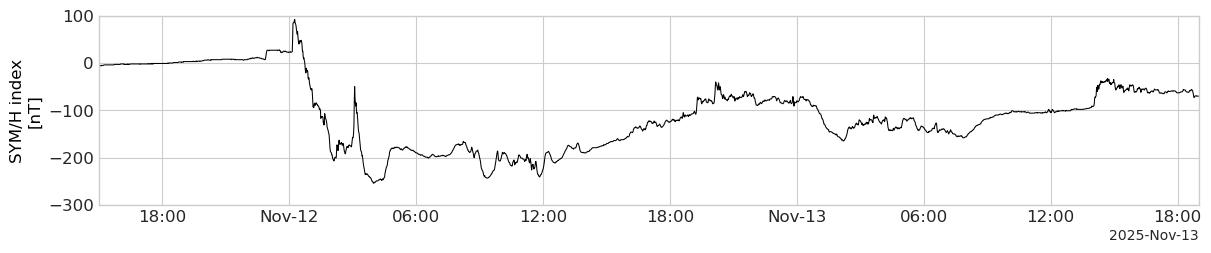

In [4]:
# Plot the SYM-H index.
vars_to_plot = ["SYM_H"]

options(vars_to_plot, "yrange", [-300, 100])
options(vars_to_plot, "alpha", 1.0)
options(vars_to_plot, "line_width", 0.75)

# Plot the geomagnetic data.
tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [5]:
# Extract data.
time_sym_h, data_sym_h = get_data("SYM_H")

# Create a DataFrame.
df = pd.DataFrame({"Time": time_sym_h, "SYM-H": data_sym_h})

# Set the time index to datetime for easier slicing.
df["Time"] = pd.to_datetime(df["Time"], unit="s")
df.set_index("Time", inplace=True)

In [6]:
# Classify geomagnetic storms into four categories.
def classify_storm(sym_h_min):
    if sym_h_min <= -250:
        return "Super"
    elif sym_h_min <= -100:
        return "Large"
    elif sym_h_min <= -50:
        return "Moderate"
    elif sym_h_min <= -30:
        return "Small"
    else:
        return "Quiet"


storms = []
threshold = -30
window_hours = 48  # Group events within 48 hours as one storm.

active_periods = df[df["SYM-H"] <= threshold]

if not active_periods.empty:
    # Group active times into discrete events.
    gaps = active_periods.index.to_series().diff() > timedelta(
        hours=window_hours
    )
    event_ids = gaps.cumsum()

    for _, group in active_periods.groupby(event_ids):
        # Define the event window.
        start = group.index.min()
        end = group.index.max()

        # Grab a slightly larger slice to ensure we see the full picture.
        storm_slice = df[
            start - timedelta(hours=12) : end + timedelta(hours=12)
        ]

        # Calculate the minimum.
        sym_h_min_val = storm_slice["SYM-H"].min()
        sym_h_min_time = storm_slice["SYM-H"].idxmin()

        storms.append(
            {
                "Classification": classify_storm(sym_h_min_val),
                "SYM-H Minimum (nT)": sym_h_min_val,
                "Time at SYM-H Minimum": sym_h_min_time,
            }
        )

In [7]:
# Display the result in a table.
results = pd.DataFrame(storms)
print(f"The number of storms identified: {len(results)}")
display(results)

The number of storms identified: 1


,Classification,SYM-H Minimum (nT),Time at SYM-H Minimum
0,Super,-254,2025-11-12 03:59:00


In [8]:
# Check each storm for Sudden Storm Commencements.
for i, row in results.iterrows():
    peak_time = row["Time at SYM-H Minimum"]
    classification = row["Classification"]

    # Define search window: 48 hours before the peak
    start_search = peak_time - timedelta(hours=48)
    end_search = peak_time

    window_df = df[start_search:end_search].copy()
    window_df["Delta_SYM-H"] = window_df["SYM-H"].diff()

    # Check for SSC Condition: An increase of >= 20 nT SYM-H in one hour
    ssc_candidates = window_df[window_df["Delta_SYM-H"] >= 20]

    print(f"\nStorm {i}: {classification}")
    print(f"  - Peak time: {peak_time}")
    print(f"  - Peak SYM-H: {row['SYM-H Minimum (nT)']} nT")

    if not ssc_candidates.empty:
        print(f"  - Potential SSC(s) found:")
        for t, jump in zip(
            ssc_candidates.index, ssc_candidates["Delta_SYM-H"]
        ):
            print(f"    * {t}: +{jump:.1f} nT jump")
    else:
        print("  - No SSC (> 20 nT jump within an hour) detected.")


Storm 0: Super
  - Peak time: 2025-11-12 03:59:00
  - Peak SYM-H: -254 nT
  - Potential SSC(s) found:
    * 2025-11-12 00:10:00: +25.0 nT jump
    * 2025-11-12 00:11:00: +34.0 nT jump
    * 2025-11-12 03:05:00: +52.0 nT jump
    * 2025-11-12 03:06:00: +29.0 nT jump


In [9]:
# Add OpenGGCM data.
RUN_NAME = "260312_1550"
RUN_DIR = pathlib.Path("/mnt/home/germaschewski/cu1010/runs") / RUN_NAME
SW_DIR = RUN_DIR / "inp"
DATA_DIR = RUN_DIR / "target"

In [10]:
# OpenGGCM input data
omni = read_ggcm_solarwind_directory(SW_DIR, glob="omni.*")
store_to_pyspedas(omni)

In [11]:
# OpenGGCM ionosphere output
iono_files = sorted(DATA_DIR.glob(f"{RUN_NAME}.iof.*00"))
iof = xr.open_mfdataset(iono_files)

02-Apr-26 17:05:47: /tmp/ipykernel_2385085/1026567936.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  iof = xr.open_mfdataset(iono_files)



In [12]:
# Calculate the AL index.
ggcm_al = iof.ggcm.al_index()
ggcmpy.timeseries.store_to_pyspedas(ggcm_al["ggcm.al"])
store_data("al", data=["AL_INDEX", "ggcm.al"])

True

In [13]:
# Calculate the cross-polar-cap-potential.
cpcp = iof.ggcm.cpcp() * 1e-3
cpcp.attrs["units"] = "kV"
store_to_pyspedas(cpcp)

In [14]:
# Calculate Joule heating.
jh = iof.ggcm.jh() * 1e-9
jh.attrs["units"] = "GW"
store_to_pyspedas(jh)

In [15]:
# Calculate OpenGGCM |dB/dt|.
delbh_t_sim = iof.ggcm.delbhdelt()

In [16]:
# Calculate |dB/dt| at magnetometer stations.
delbh_t_sim_station = iof.ggcm.delbhdelt_station()

In [17]:
# Extract data and coordinates from the `delbh_t_sim_station` DataArray.
times = delbh_t_sim_station.time
stations = delbh_t_sim_station.station

var_names = []

# Store each station data.
for station in stations.values:
    var_name = f"delbh_t_sim_{station}"
    station_data = delbh_t_sim_station.sel(station=station).values
    store_data(var_name, data={"x": times, "y": station_data})
    var_names.append(var_name)

store_data("delbh_t_sim_all", data=var_names)

True

In [18]:
# Find the simulation |dB/dt| maximum and the magnetometer station where it occurs.
station_max_sim_name = delbh_t_sim_station.isel(
    delbh_t_sim_station.argmax(dim=["time", "station"])
).station.item()
station_max_sim_time = delbh_t_sim_station.isel(
    delbh_t_sim_station.argmax(dim=["time", "station"])
).time.values

print(
    "The simulation data maximum at a station is",
    delbh_t_sim_station.max().item(),
    "nT/s occurring at",
    station_max_sim_name,
    "at",
    station_max_sim_time,
    ".",
)

The simulation data maximum at a station is 3.5459084510803223 nT/s occurring at CCS at 2025-11-12T02:20:00.000000000 .


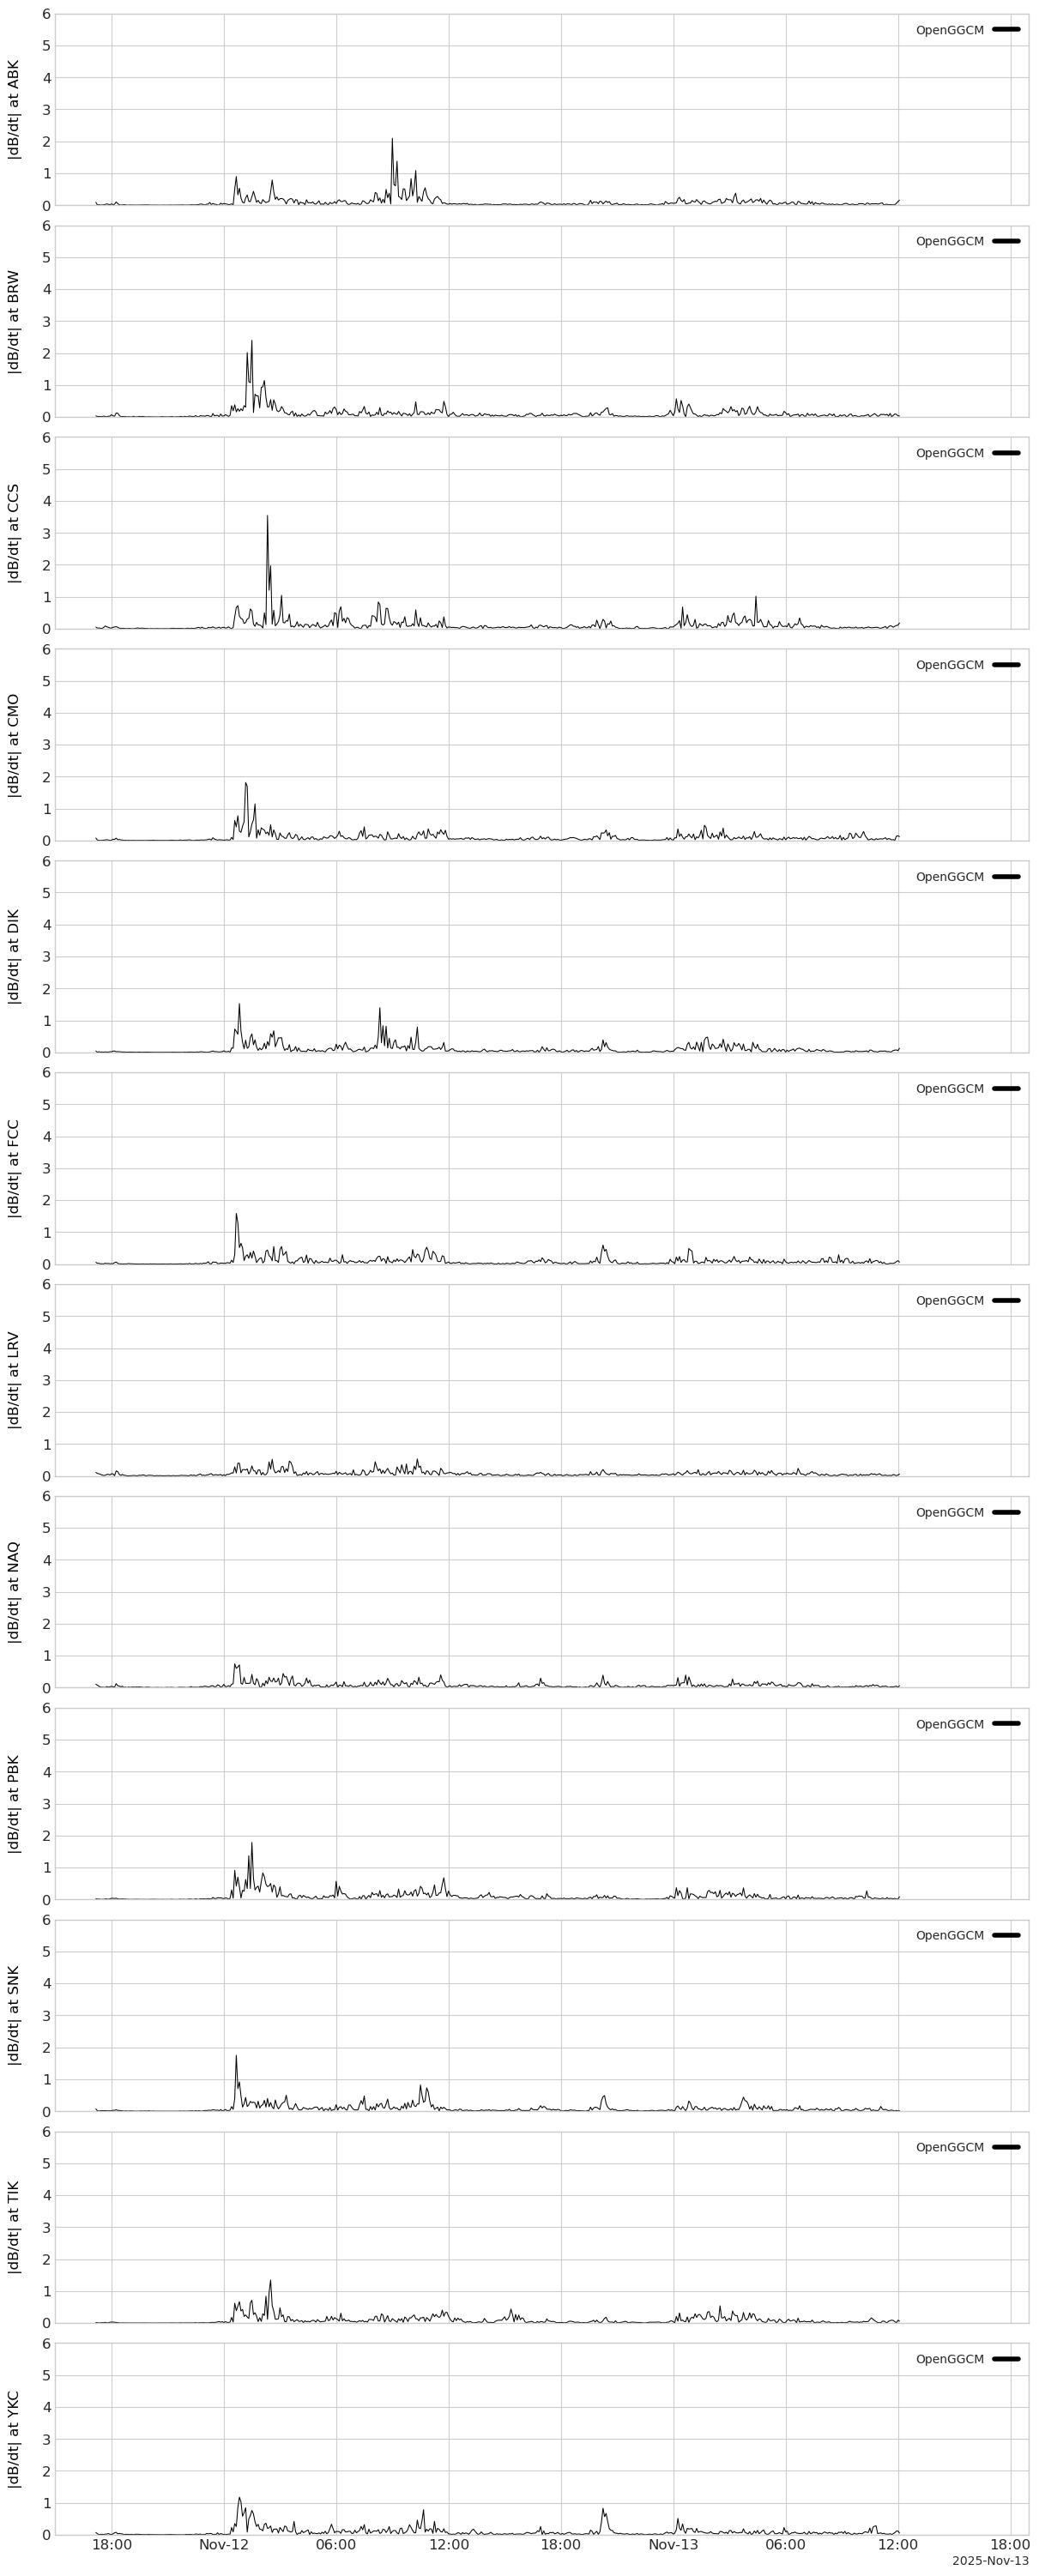

In [19]:
# Plot OpenGGCM |dB/dt| at each station.
vars_to_plot = []

for station in stations:
    vars_to_plot.append(
        f"delbh_t_sim_{station.values}",
    )
    options(
        f"delbh_t_sim_{station.values}",
        "ytitle",
        f"|dB/dt| at {station.values}",
    )

# options(vars_to_plot, "yrange", [0, delbh_t_sim_station.max().item()])
options(vars_to_plot, "yrange", [0, 6])
options(vars_to_plot, "alpha", 1.0)
options(vars_to_plot, "line_width", 0.75)
options(vars_to_plot, "legend_names", "OpenGGCM")
options(vars_to_plot, "legend_location", "upper right")

# Plot |dB/dt| at each station with a uniform `yrange`.
tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [20]:
# Calculate observed |dB/dt|.
# Map magnetometer names between OMNI and THEMIS.
MAP_THEMIS_STATIONS = {
    # CANOPUS -> CARISMA/THEMIS
    "BK": "back",
    "CL": "cont",
    "DC": "daws",
    "EP": "eski",
    "FC": "fcc",
    "FM": "mcmu",
    "FS": "fsim",
    "SM": "fsmi",
    "GI": "gill",
    "IL": "isll",
    "PI": "pina",
    "RB": "rabb",
    "RI": "rank",
    # AL
    "ABK": "abk",
    "BRW": "brw",
    # "CCS": "",
    "CMO": "cmo",
    # "DIK": "",
    "FCC": "fcc",
    "LRV": "lrv",
    "NAQ": "naq",
    # "PBK": "",
    "SNK": "snkq",
    # "TIK": "",
    "YKC": "ykc",
}

# Create a list of magnetometer stations using THEMIS station codes.
station_list_obs = [
    MAP_THEMIS_STATIONS[str(station.values)]
    for station in stations
    if str(station.values) in MAP_THEMIS_STATIONS
]

pyspedas.projects.themis.gmag(
    sites=station_list_obs, trange=trange, time_clip=True
)

02-Apr-26 17:22:03: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/abk/2025/
02-Apr-26 17:22:05: File is current: themis_data/thg/l2/mag/abk/2025/thg_l2_mag_abk_20251111_v01.cdf
02-Apr-26 17:22:06: File is current: themis_data/thg/l2/mag/abk/2025/thg_l2_mag_abk_20251112_v01.cdf
02-Apr-26 17:22:07: File is current: themis_data/thg/l2/mag/abk/2025/thg_l2_mag_abk_20251113_v01.cdf
02-Apr-26 17:22:07: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/brw/2025/
02-Apr-26 17:22:09: File is current: themis_data/thg/l2/mag/brw/2025/thg_l2_mag_brw_20251111_v01.cdf
02-Apr-26 17:22:10: File is current: themis_data/thg/l2/mag/brw/2025/thg_l2_mag_brw_20251112_v01.cdf
02-Apr-26 17:22:11: File is current: themis_data/thg/l2/mag/brw/2025/thg_l2_mag_brw_20251113_v01.cdf
02-Apr-26 17:22:11: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/cmo/2025/
02-Apr-26 17:22:13: File is current: themis_data/thg/l2/mag/c

['thg_mag_naq',
 'thg_mag_abk',
 'thg_mag_brw',
 'thg_mag_cmo',
 'thg_mag_fcc',
 'thg_mag_lrv',
 'thg_mag_snkq',
 'thg_mag_ykc']

In [21]:
from scipy.signal import butter, filtfilt

# Define filter parameters (e.g., 1/600 Hz cutoff for a 300 s OpenGGCM output interval).
fs = 1.0 / 60.0
cutoff = 1.0 / ((iof.time[1] - iof.time[0]).item() * 1e-9 * 2)
b, a = butter(2, (cutoff / (0.5 * fs)), btype="low", analog=False)

station_max_obs_value_dict = {}

# Process the observation data.
for station in stations:
    station_str = str(station.values)

    if station_str not in MAP_THEMIS_STATIONS:
        continue

    themis_station = MAP_THEMIS_STATIONS[station_str]
    var_obs_raw = f"thg_mag_{themis_station}"

    # Store the output under original station names.
    var_obs = f"delbh_t_obs_{station_str}"

    if data_exists(var_obs_raw):
        data_obs = get_data(var_obs_raw)
        times = data_obs.times

        # THEMIS GMAG [H, E, Z]
        delbn_raw = data_obs.y[:, 0]
        delbe_raw = data_obs.y[:, 1]

        # Apply the filter.
        delbn_filtered = filtfilt(b, a, delbn_raw)
        delbe_filtered = filtfilt(b, a, delbe_raw)

        # Calculate the derivatives.
        dt = np.diff(times)
        delbn_t = np.diff(delbn_filtered) / dt
        delbe_t = np.diff(delbe_filtered) / dt

        # Calculate the magnitude.
        delbh_t_obs = np.sqrt(delbn_t**2 + delbe_t**2)
        times = times[1:]

        station_max_obs_value_dict[f"{station_str}"] = delbh_t_obs.max().item()
        store_data(var_obs, data={"x": times, "y": delbh_t_obs})

In [22]:
# Find the observation |dB/dt| maximum and the magnetometer station where it occurs.
for key, value in station_max_obs_value_dict.items():
    if value == max(station_max_obs_value_dict.values()):
        station_max_obs_name = key
        break

print(
    "The observation data maximum is",
    max(station_max_obs_value_dict.values()),
    "nT/s occurring at",
    station_max_obs_name,
    ".",
)

The observation data maximum is 767.039397074444 nT/s occurring at SNK .


In [23]:
# Plot both observation and simulation |dB/dt| at each station.
vars_to_plot = []

for station in stations:
    station_str = str(station.values)
    var_sim = f"delbh_t_sim_{station_str}"
    var_obs = f"delbh_t_obs_{station_str}"
    var_combined = f"compare_{station_str}"

    if data_exists(var_obs):
        store_data(var_combined, data=[var_obs, var_sim])
        options(var_combined, "legend_names", ["SuperMAG", "OpenGGCM"])
        options(var_combined, "color", ["black", "red"])
    else:
        store_data(var_combined, data=var_sim)
        options(var_combined, "legend_names", ["OpenGGCM"])
        options(var_combined, "color", ["red"])

    options(var_combined, "ytitle", f"|dB/dt| at {station_str}")
    vars_to_plot.append(var_combined)

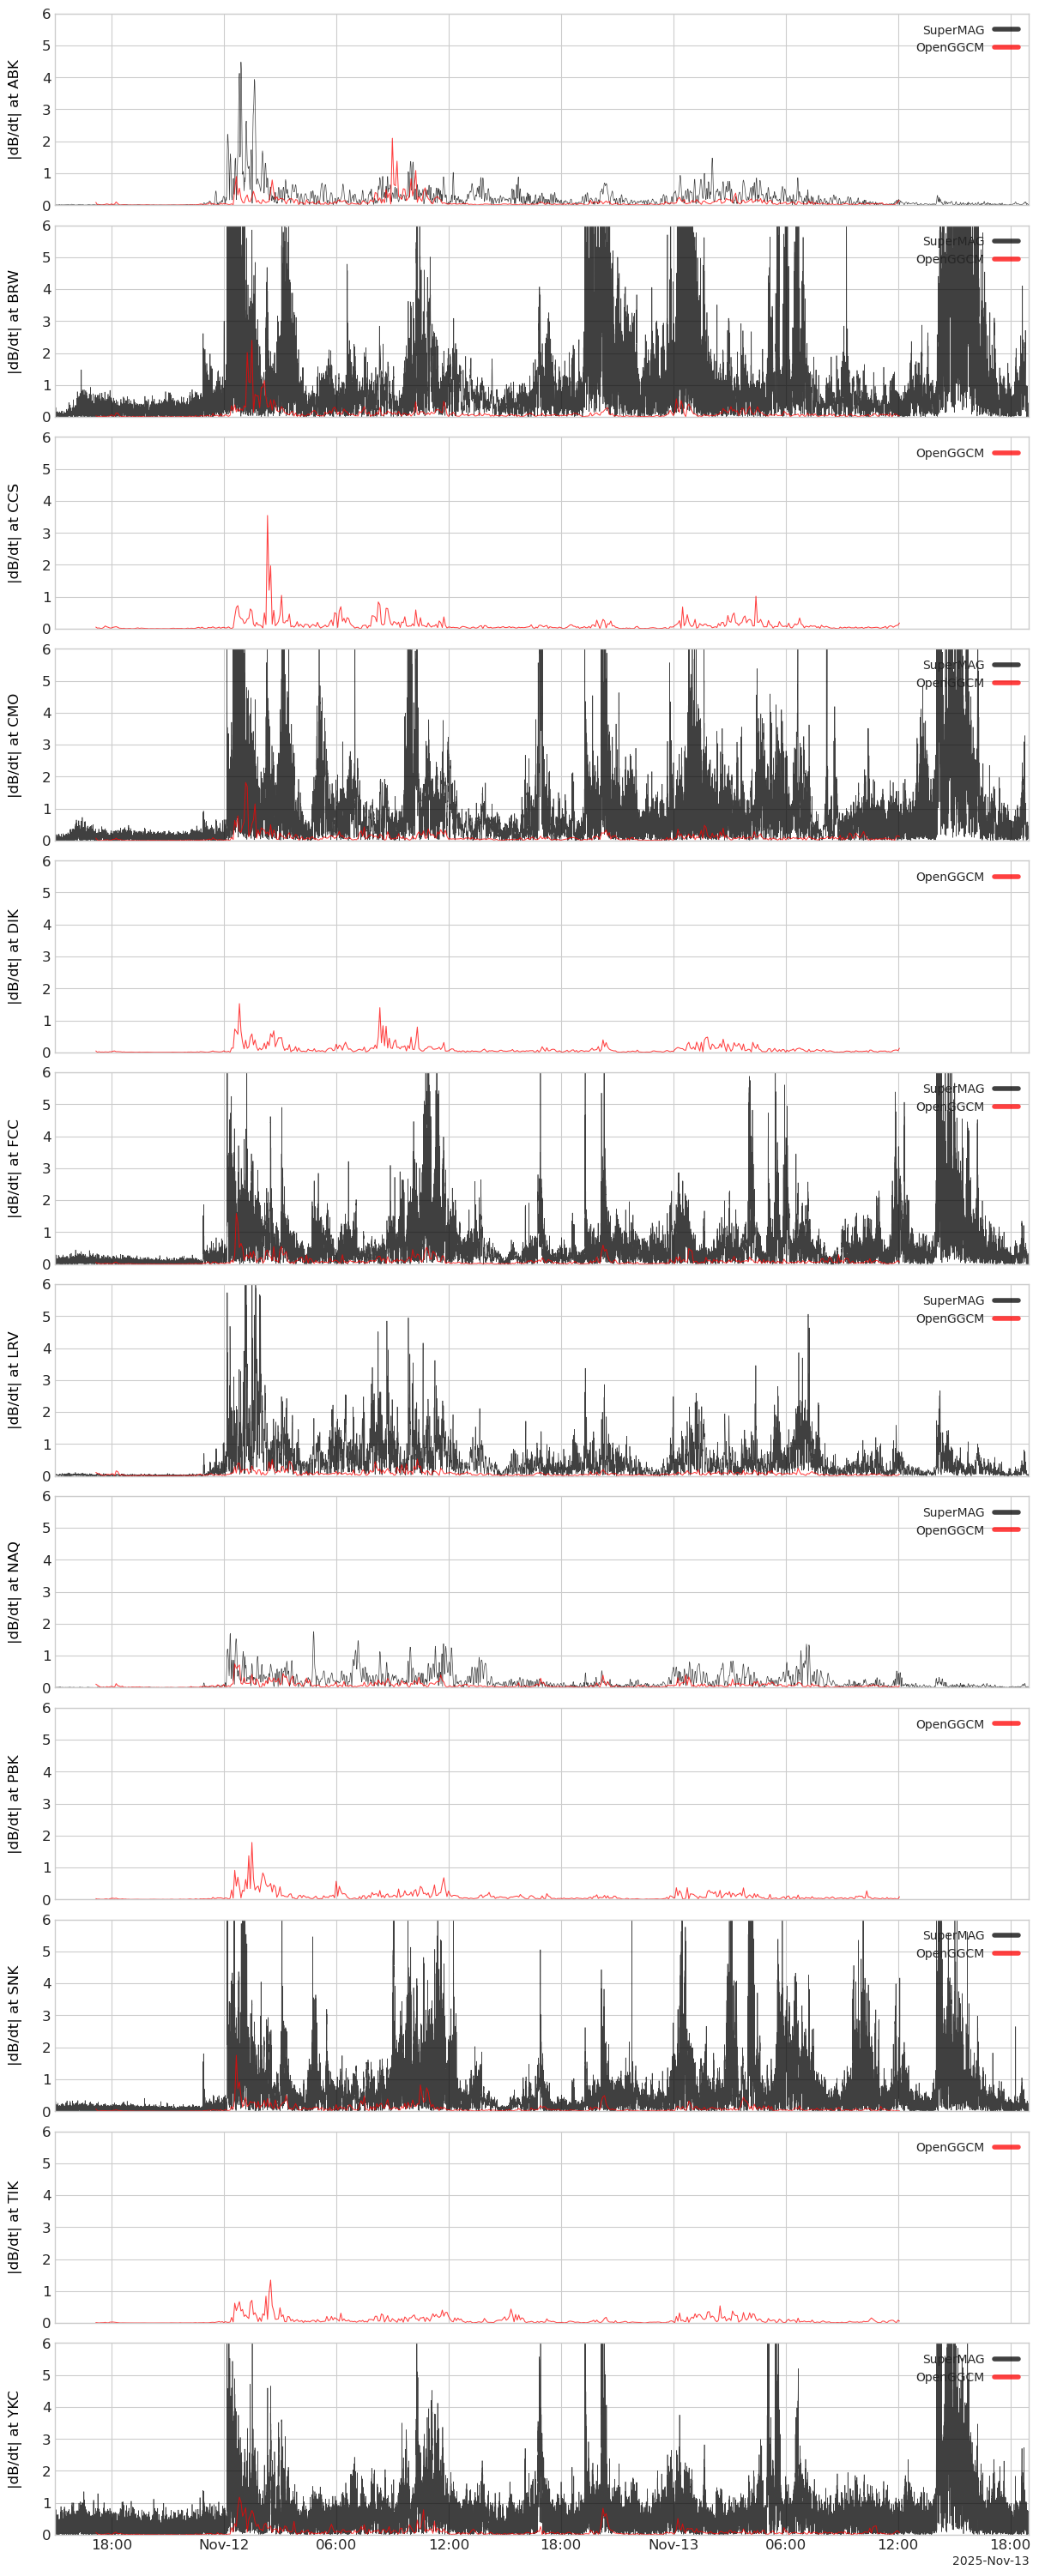

In [24]:
# options(vars_to_plot, "yrange", [0, delbh_t_sim_station.max().item()])
options(vars_to_plot, "yrange", [0, 6])
options(vars_to_plot, "alpha", 0.75)
# options(vars_to_plot, "line_width", 0.75)

# Plot |dB/dt| at each station.
tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [25]:
# Set geomagnetic data plotting options.

# IMF Bz
options("BZ_GSE", "ytitle", "IMF Bz")
options("BZ_GSE", "yrange", [-60, 40])

# Solar Wind Speed
options("flow_speed", "ytitle", "Speed")

# Solar Wind Density
options("proton_density", "ytitle", "Density")
options("proton_density", "ylog", True)
options("proton_density", "yrange", [1, 100])

# Flow Pressure (Dynamic Pressure)
options("Pressure", "ytitle", "Dyn. Pressure")

# AE Index
options("AE_INDEX", "ytitle", "AE Index")

# AL Index
options("al", "ytitle", "AL Index")
options("al", "yrange", [-4000, 0])
options("al", "color", ["black", "red"])
options("al", "legend_names", ["OMNI", "OpenGGCM"])
options("al", "legend_location", "lower right")

# CPCP
options("cpcp_north", "yrange", [0, 800])
options("cpcp_north", "legend_names", "OpenGGCM")
options("cpcp_north", "legend_location", "upper right")

# Joule heating
options("jh_north", "ylog", True)
options("jh_north", "yrange", [1, 10000])
options("jh_north", "legend_names", "OpenGGCM")
options("jh_north", "legend_location", "upper right")

# |dB/dt| at the station with the maximum OpenGGCM |dB/dt| value
options(
    f"delbh_t_sim_{station_max_sim_name}",
    "yrange",
    # [0, delbh_t_sim_station.max().values.item()],
    [0, 6],
)
options(f"delbh_t_sim_{station_max_sim_name}", "legend_names", "OpenGGCM")
options(
    f"delbh_t_sim_{station_max_sim_name}", "legend_location", "upper right"
)

# |dB/dt| at the station with the maximum OpenGGCM / SuerMAG |dB/dt| value
options(f"compare_{station_max_sim_name}", "yrange", [0, 6])
options(f"compare_{station_max_obs_name}", "yrange", [0, 6])

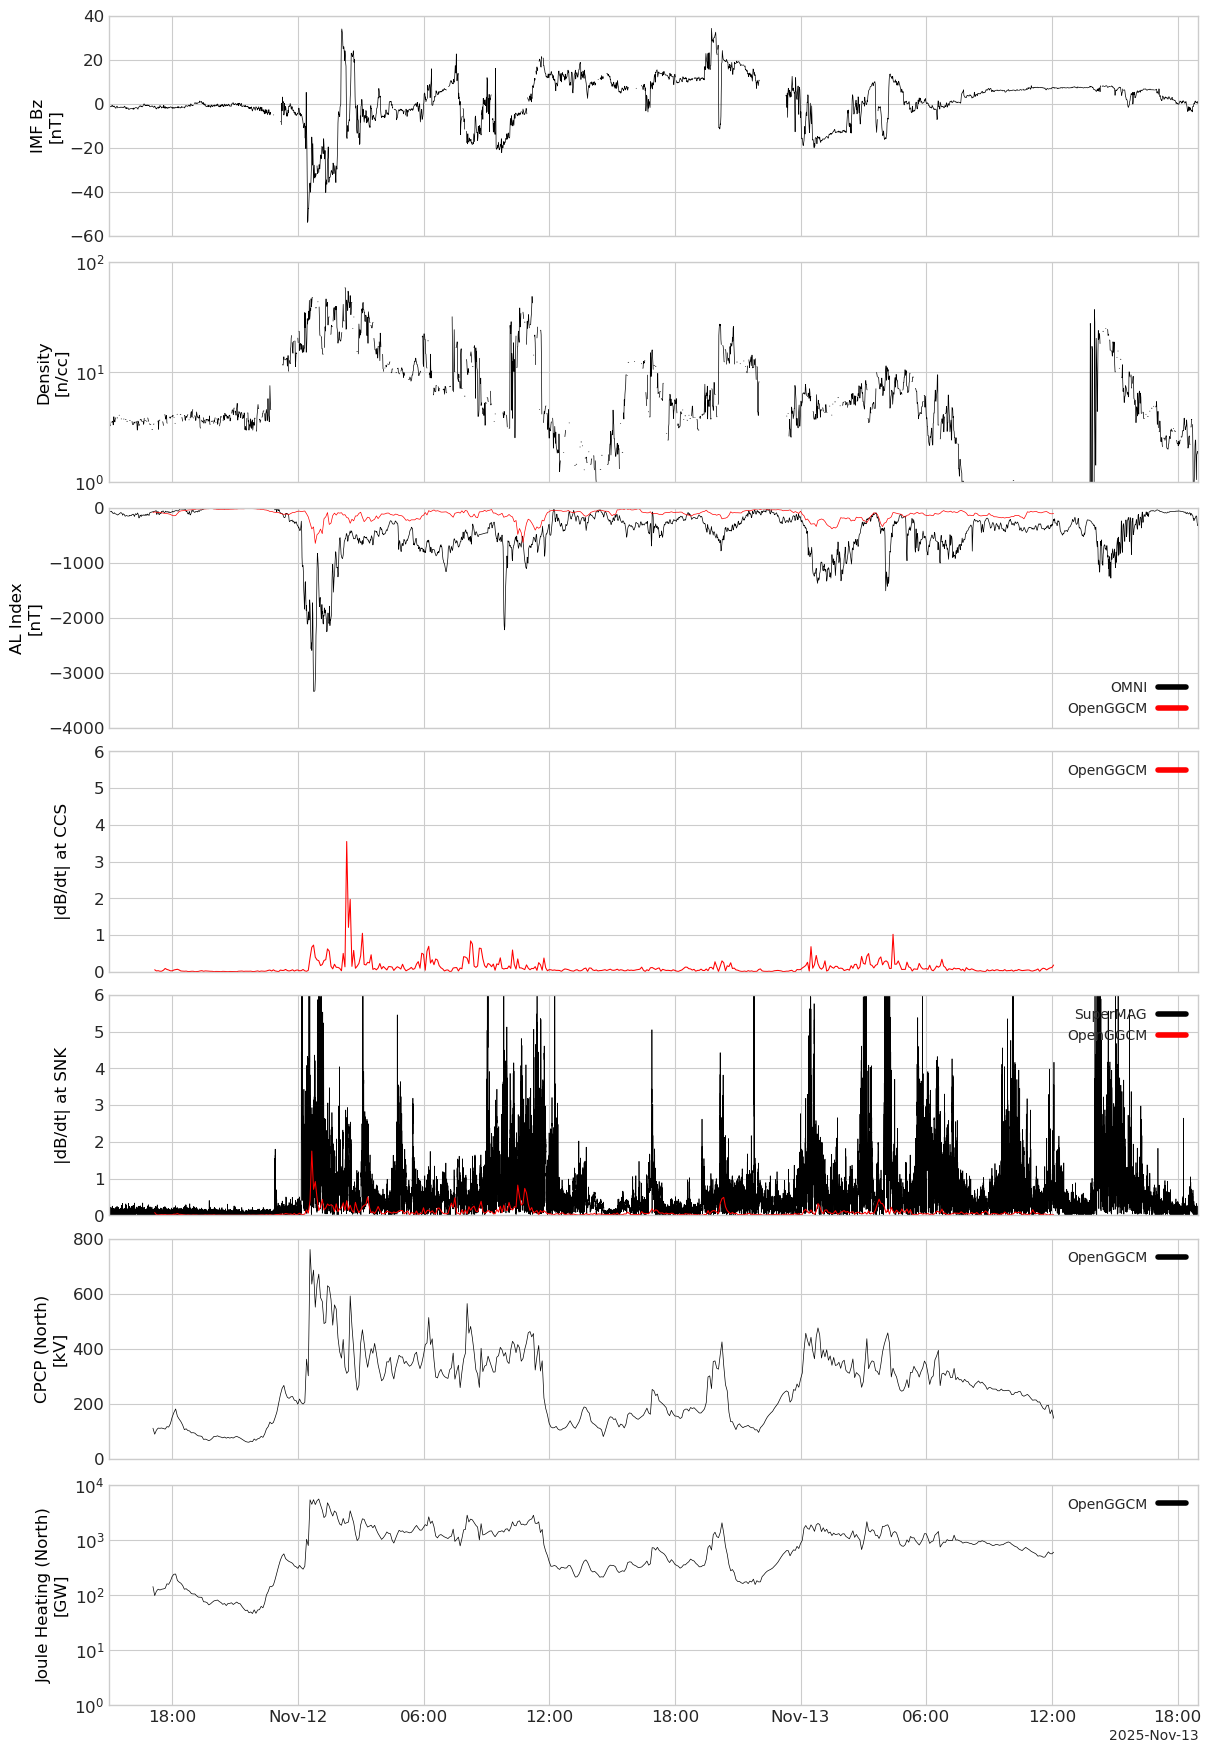

In [26]:
vars_to_plot = [
    "BZ_GSE",
    "proton_density",
    # "flow_speed",
    # "SYM_H",
    "al",
    # f"delbh_t_sim_{station_max_sim_name}",
    f"compare_{station_max_sim_name}",
    f"compare_{station_max_obs_name}",
    "cpcp_north",
    "jh_north",
]

options(vars_to_plot, "alpha", 1.0)
# options(vars_to_plot, "line_width", 0.75)

# Plot the geomagnetic data.
tplot(vars_to_plot, trange, ysize=2.5 * len(vars_to_plot))

In [27]:
mag_files = sorted(DATA_DIR.glob(f"{RUN_NAME}.py_0.*"))
py_0 = xr.open_mfdataset(mag_files)

02-Apr-26 17:23:35: /tmp/ipykernel_2385085/343765521.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  py_0 = xr.open_mfdataset(mag_files)



In [28]:
# Determine the maximum time step and interval.
time_max = iof.time.shape[0]
interval = int(time_max / 6)

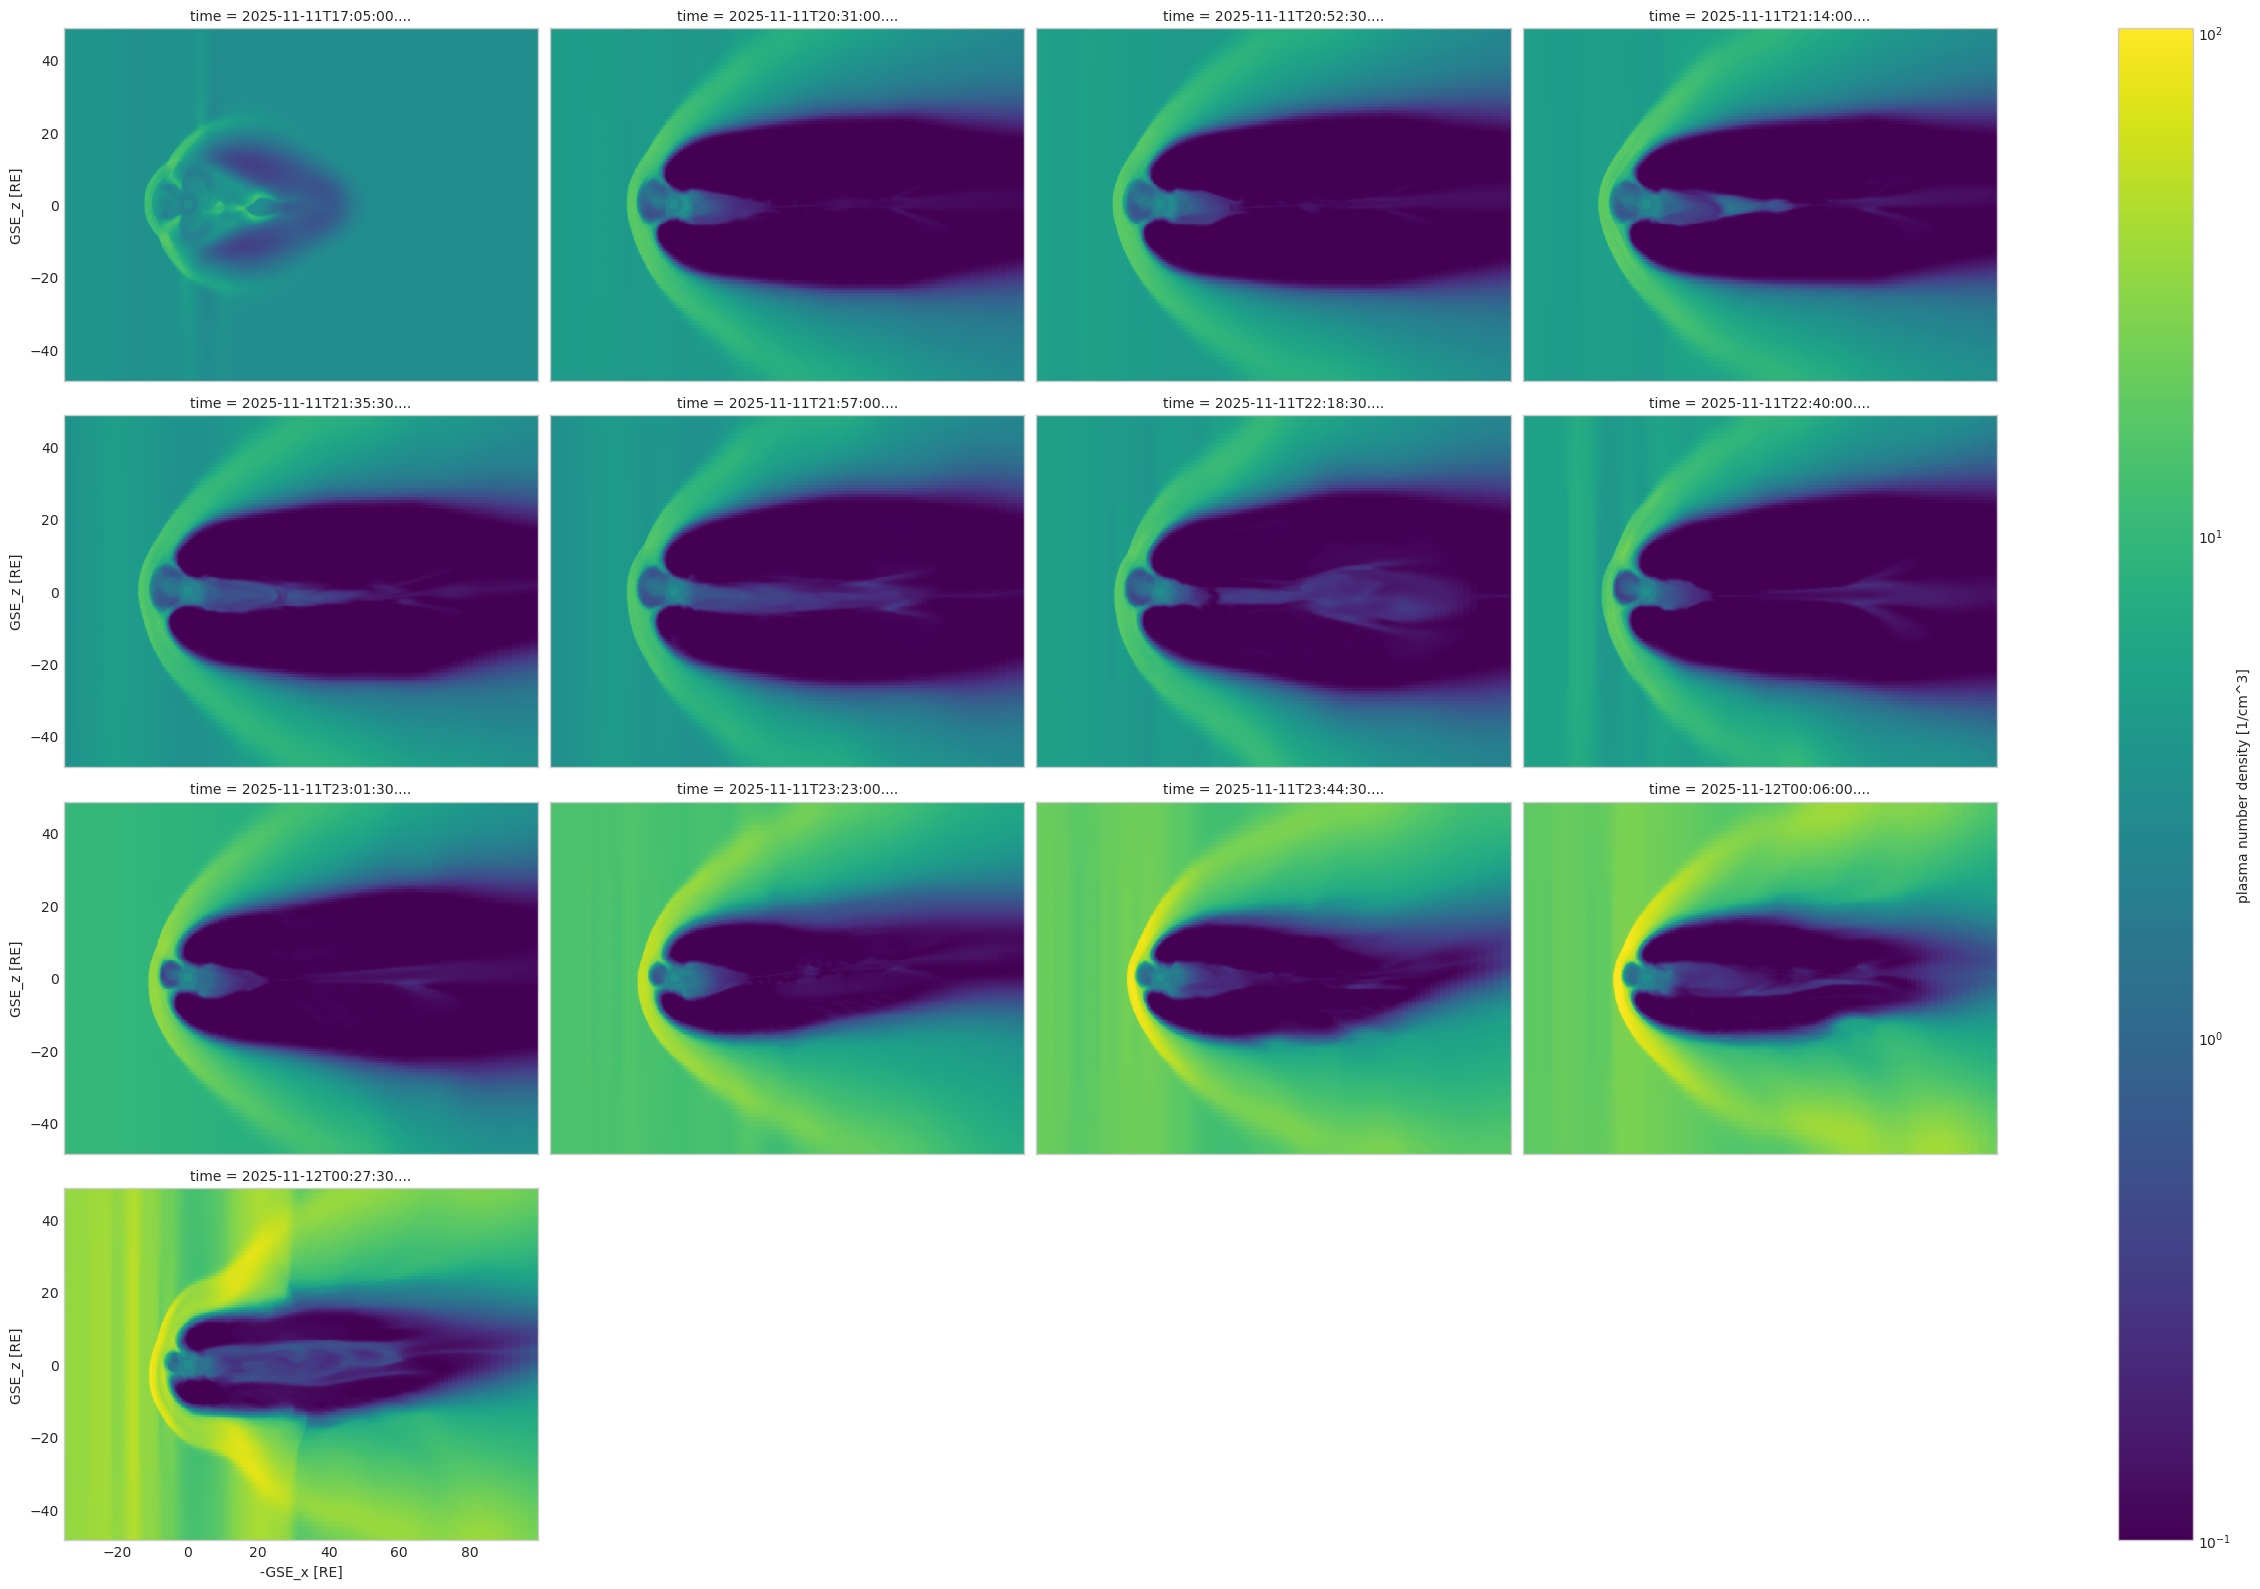

In [29]:
# Density
py_0.rr.sel(x=slice(-50.0, 100.0), z=slice(-50.0, 50.0)).isel(
    time=slice(0, time_max, int(interval / 2))
).T.plot(col="time", col_wrap=4, aspect=1.5, size=4, norm=colors.LogNorm());

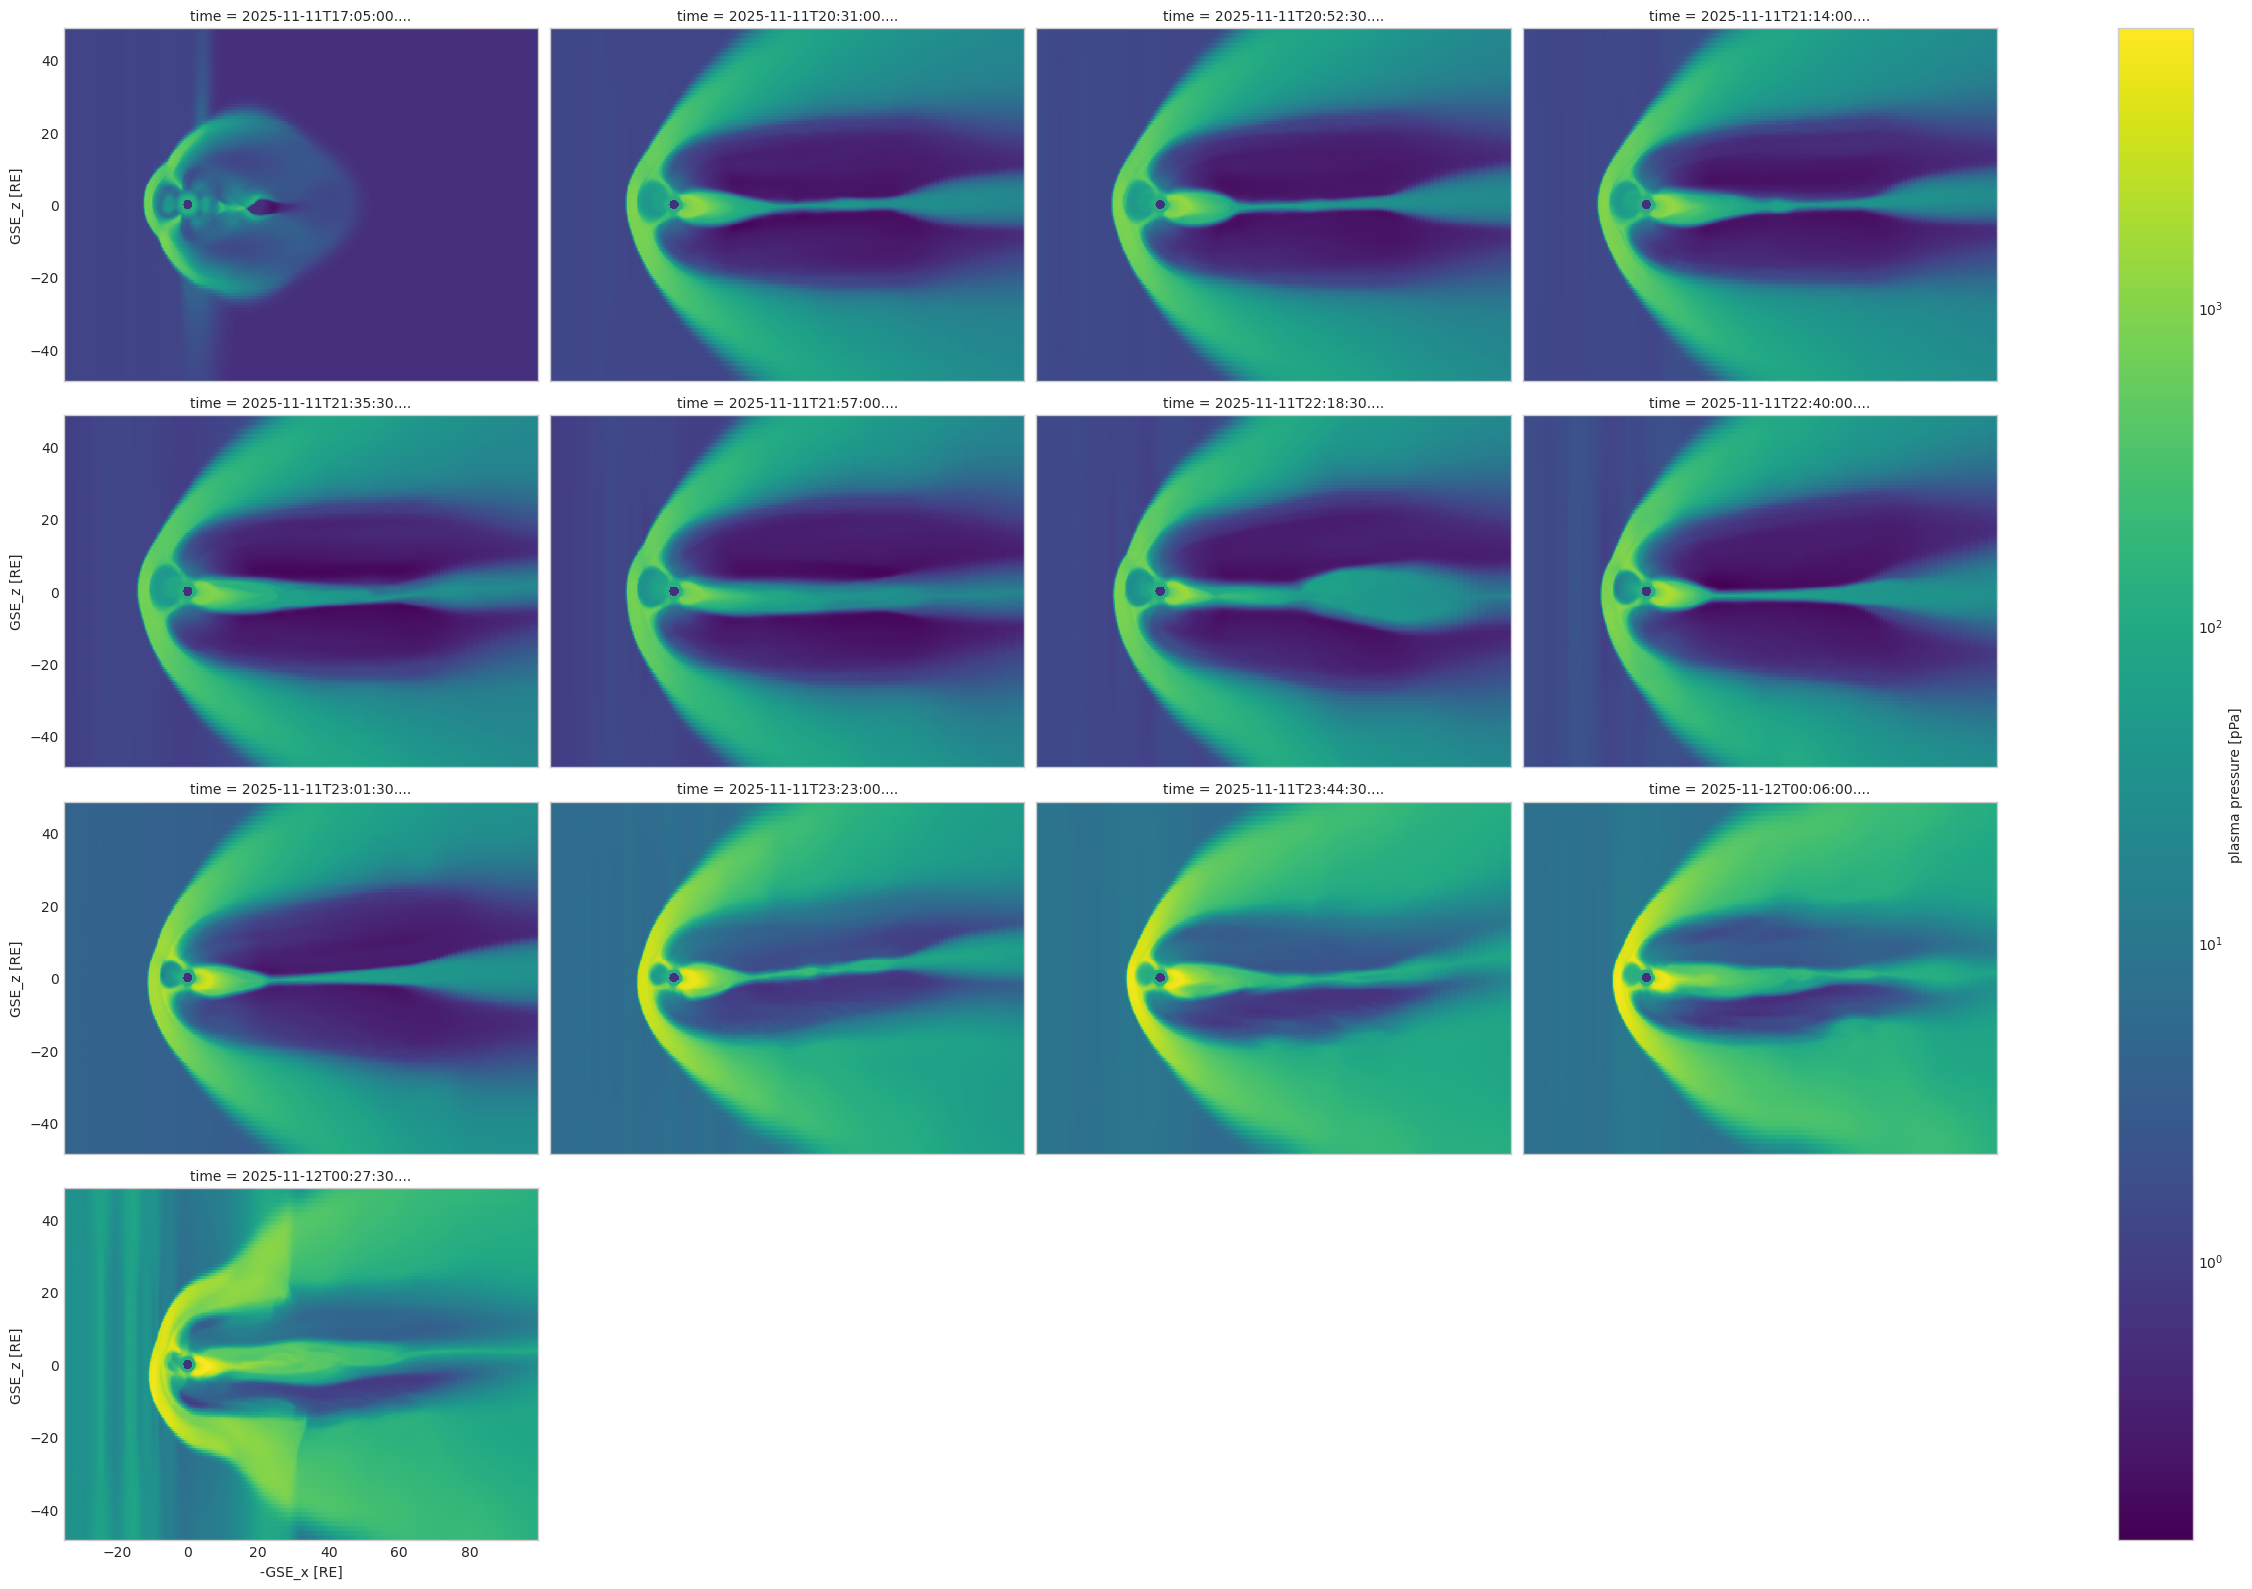

In [30]:
# Pressure
py_0.pp.sel(x=slice(-50.0, 100.0), z=slice(-50.0, 50.0)).isel(
    time=slice(0, time_max, int(interval / 2))
).T.plot(col="time", col_wrap=4, aspect=1.5, size=4, norm=colors.LogNorm());

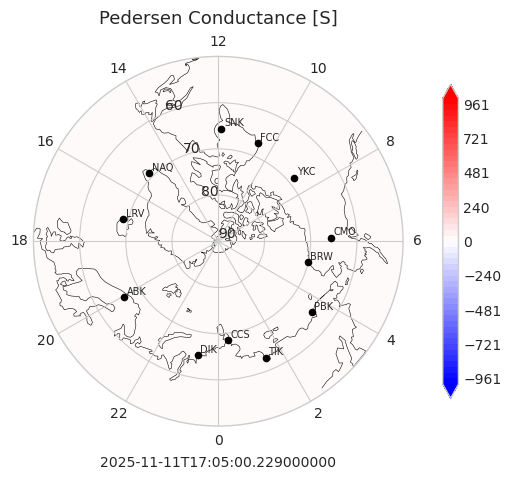

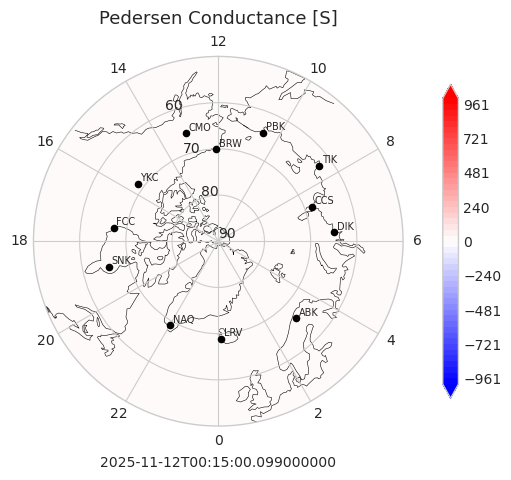

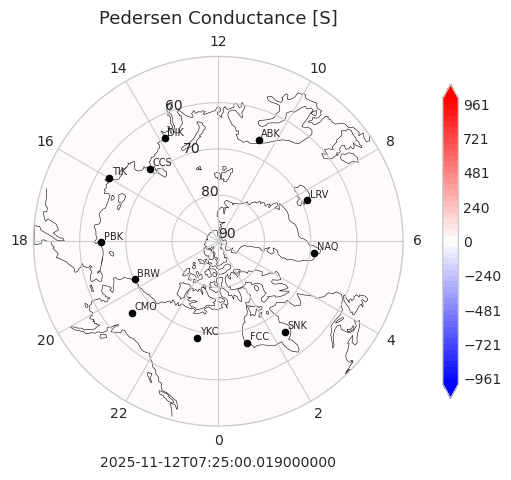

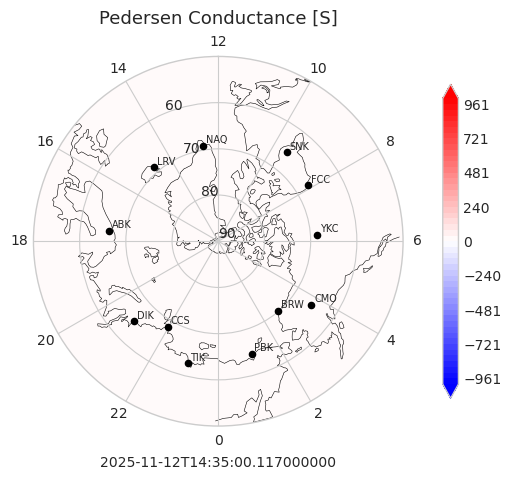

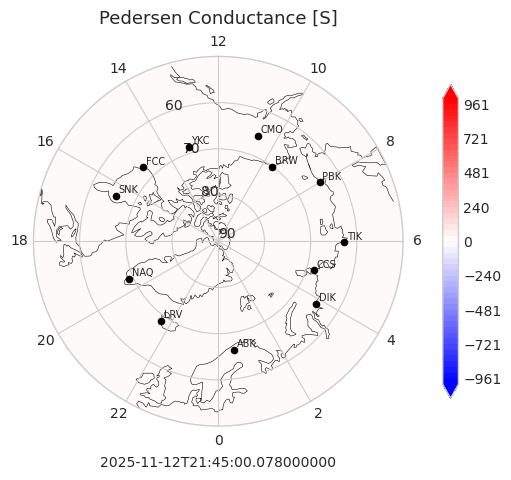

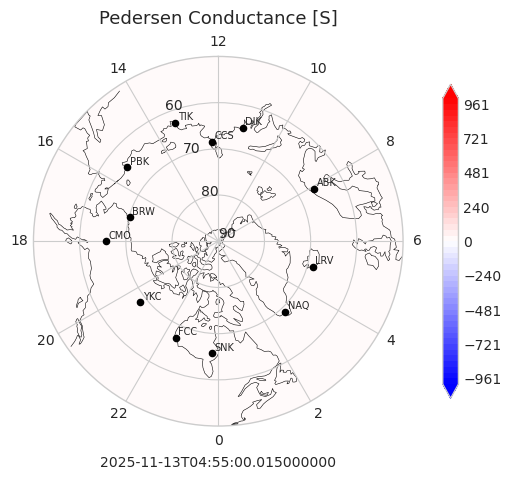

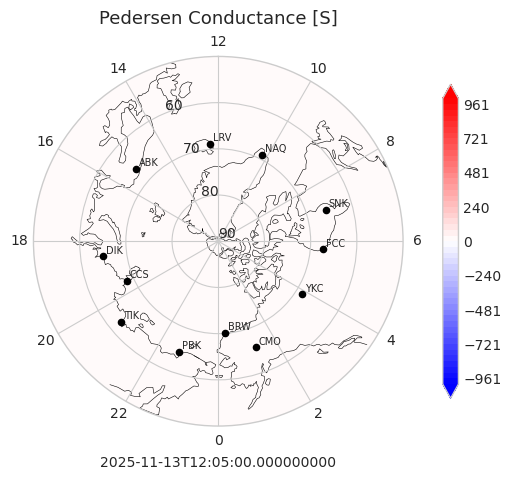

In [31]:
# Pedersen and Hall conductances
abs_max = abs(iof.sigp).max().values
levels = np.linspace(-abs_max, abs_max, 51)

for i in range(0, time_max, interval):
    iof.isel(time=i).sigp.ggcm.plot(
        coastlines=True,
        stations=True,
        levels=levels,
        timestamp=True,
    )

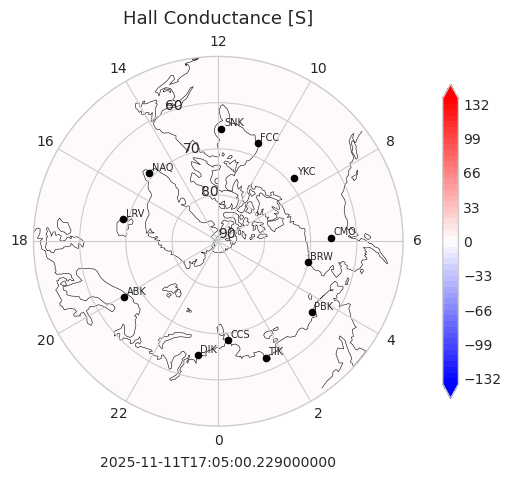

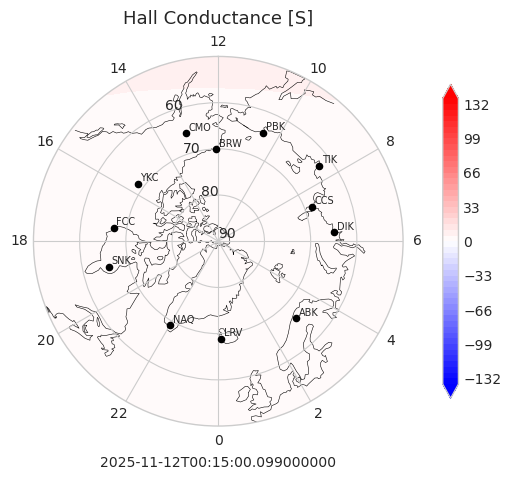

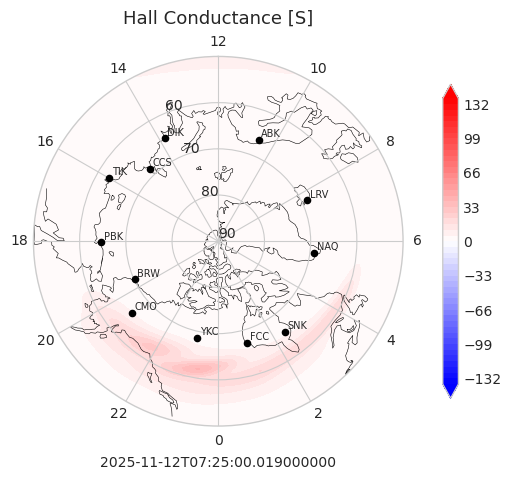

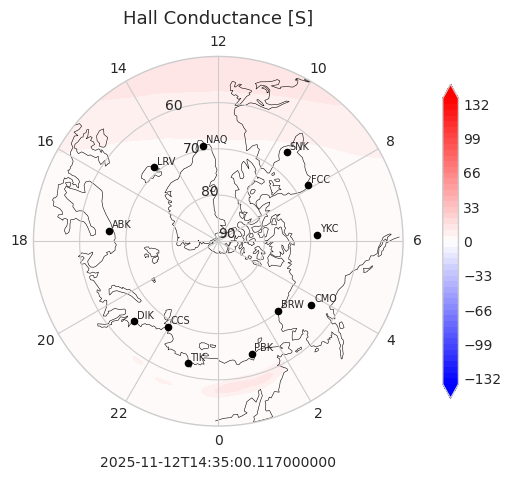

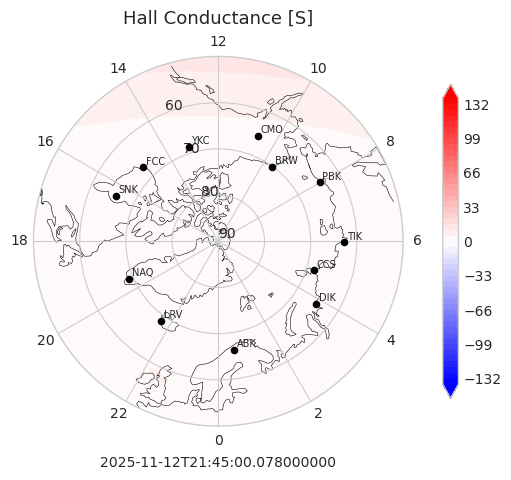

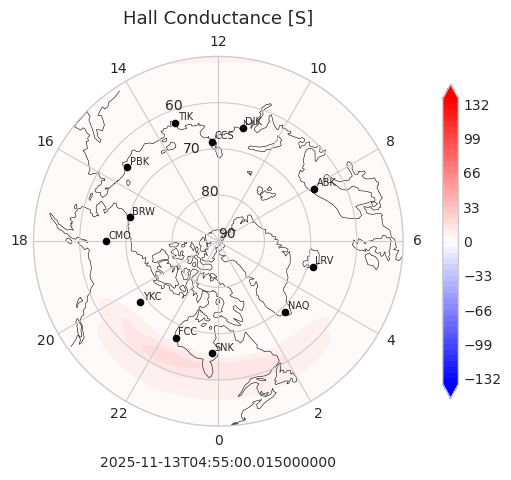

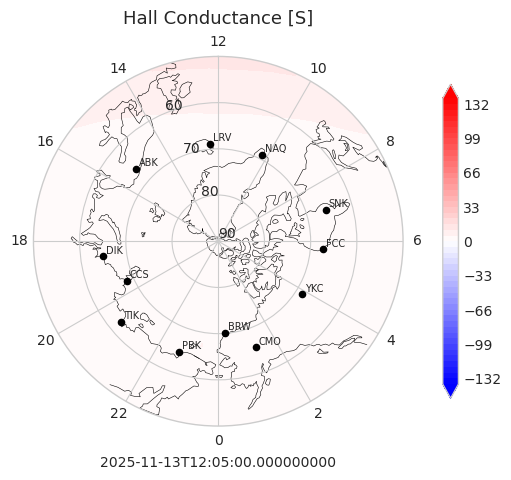

In [32]:
abs_max = abs(iof.sigh).max().values
levels = np.linspace(-abs_max, abs_max, 51)

for i in range(0, time_max, interval):
    iof.isel(time=i).sigh.ggcm.plot(
        coastlines=True,
        stations=True,
        levels=levels,
        timestamp=True,
    )

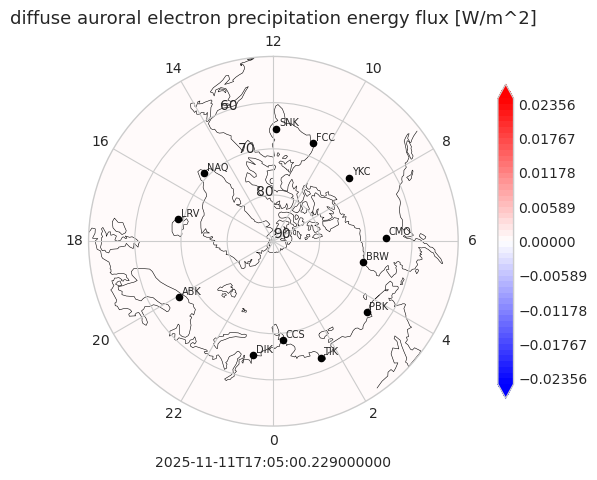

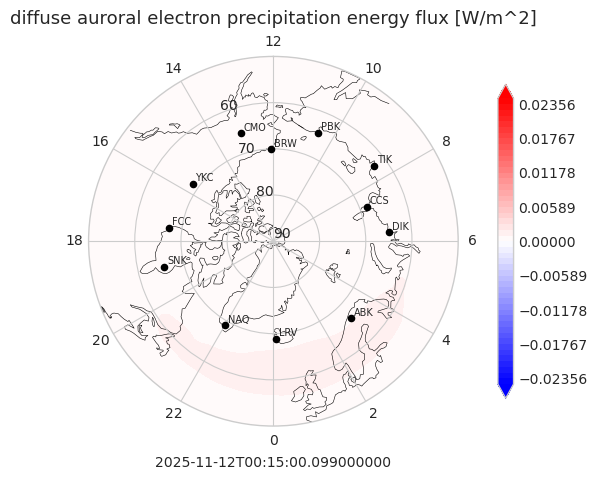

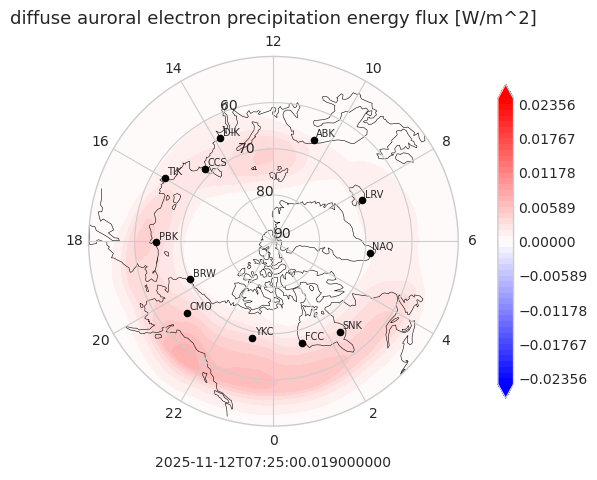

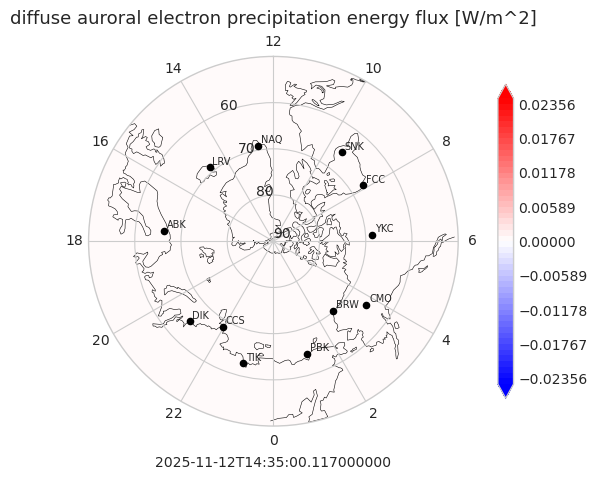

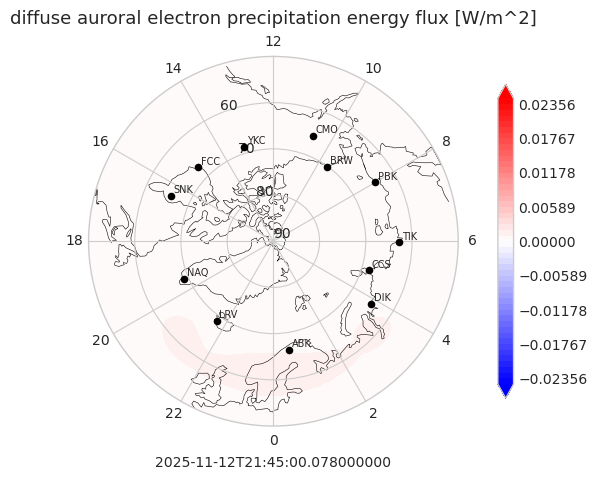

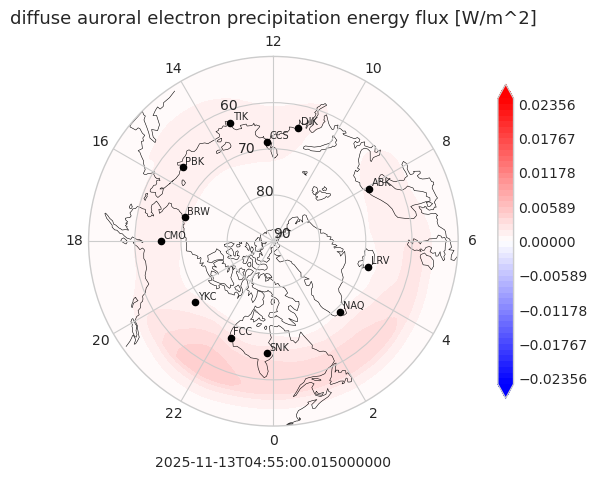

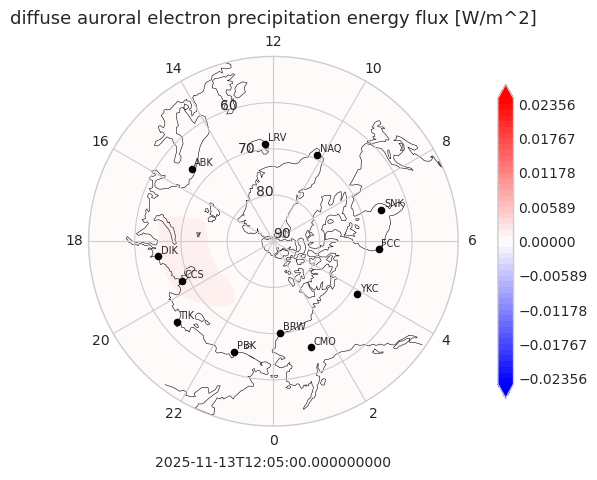

In [33]:
# Diffuse and discrete electron precipitation energy flux
abs_max = abs(iof.prec_e_fe_1).max().values
levels = np.linspace(-abs_max, abs_max, 51)

for i in range(0, time_max, interval):
    iof.isel(time=i).prec_e_fe_1.ggcm.plot(
        coastlines=True,
        stations=True,
        levels=levels,
        timestamp=True,
    )

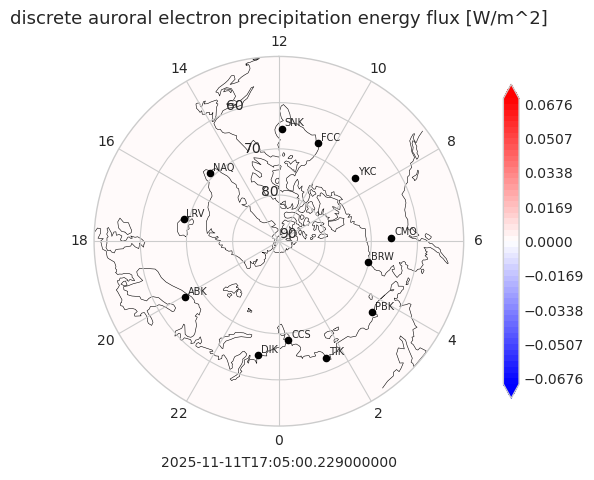

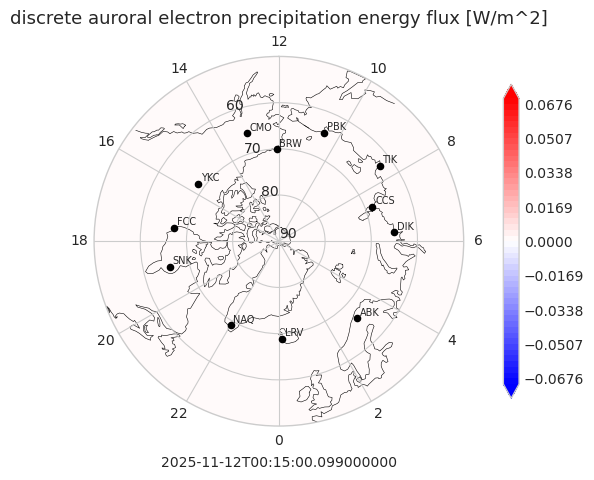

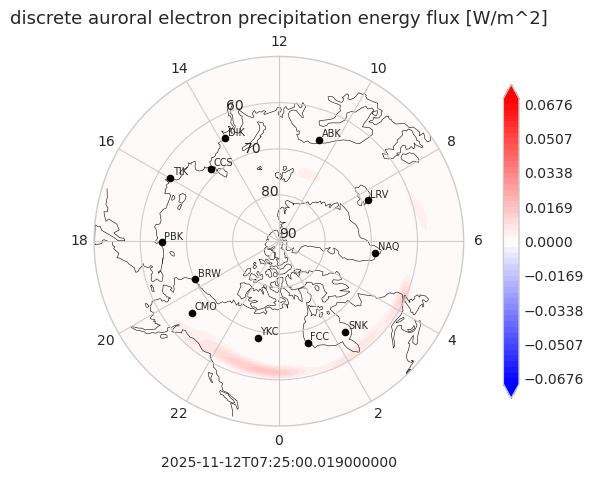

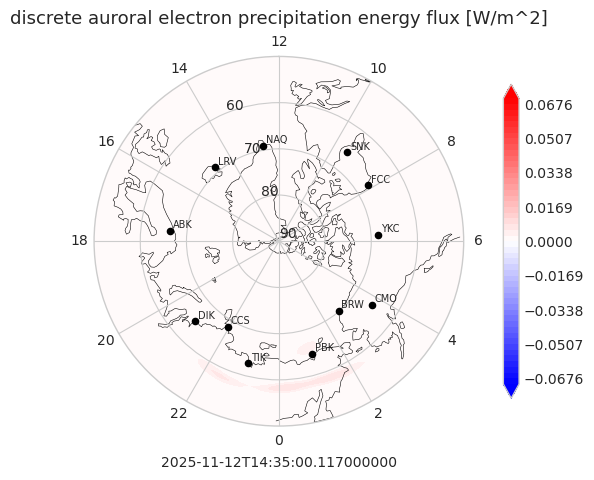

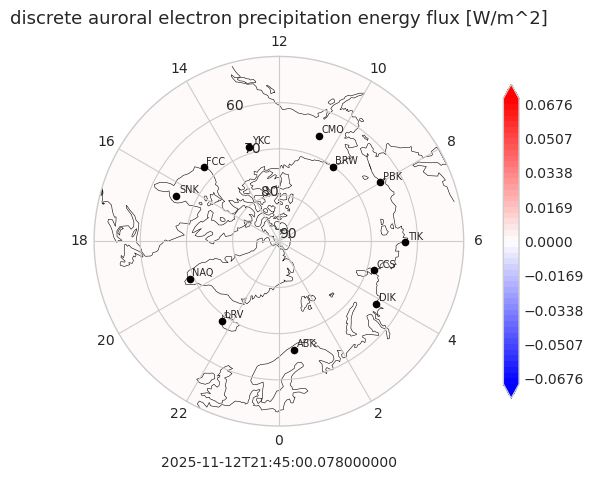

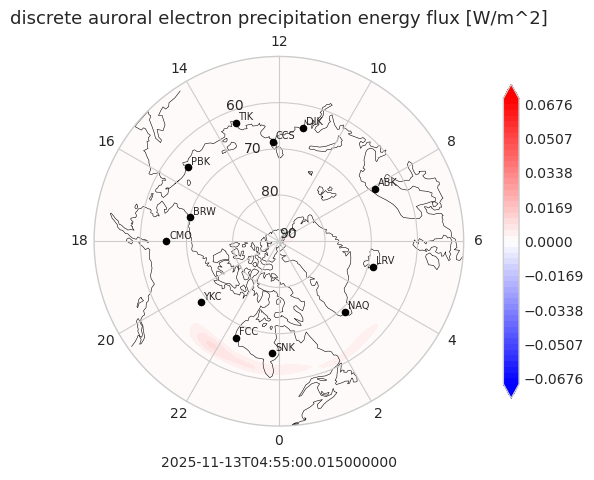

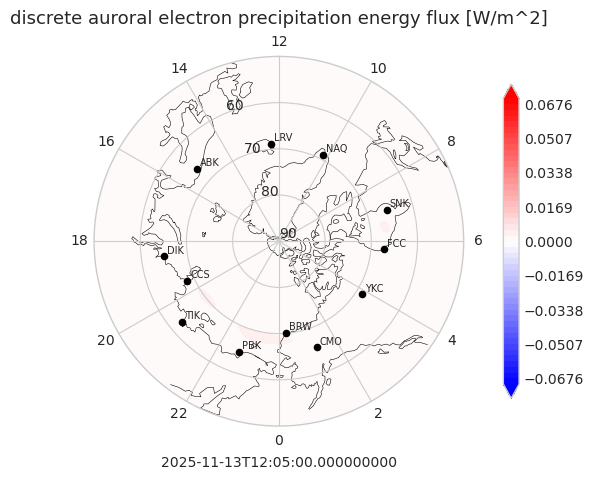

In [34]:
abs_max = abs(iof.prec_e_fe_2).max().values
levels = np.linspace(-abs_max, abs_max, 51)

for i in range(0, time_max, interval):
    iof.isel(time=i).prec_e_fe_2.ggcm.plot(
        coastlines=True,
        stations=True,
        levels=levels,
        timestamp=True,
    )

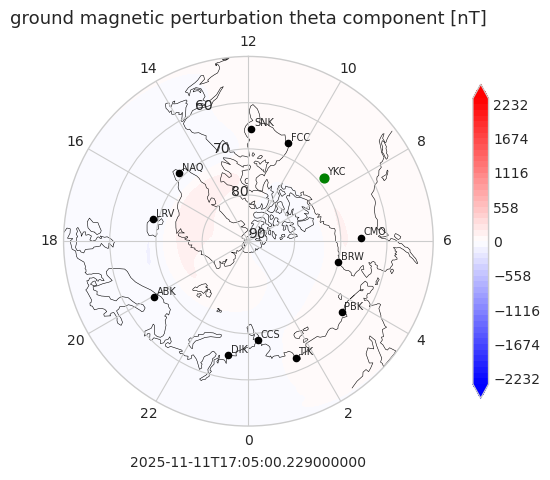

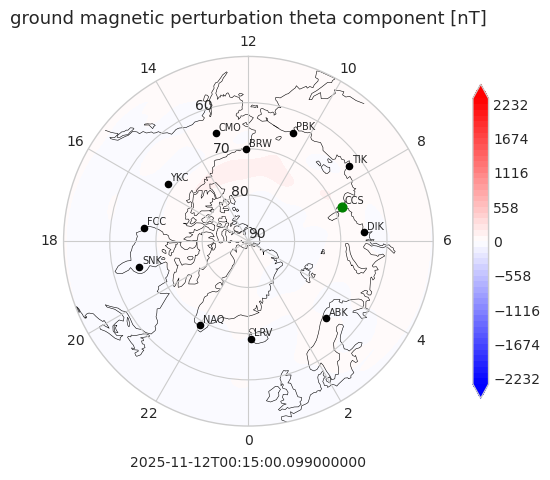

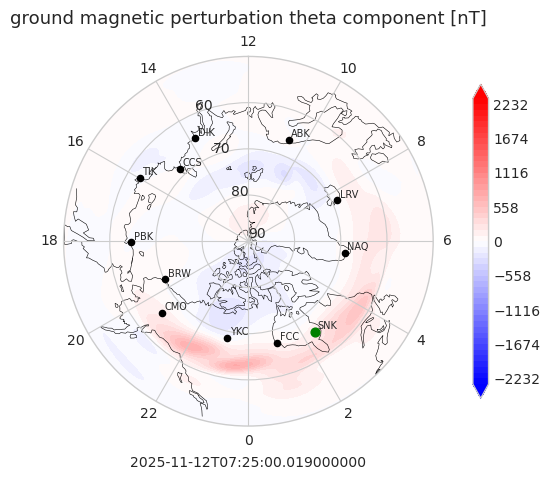

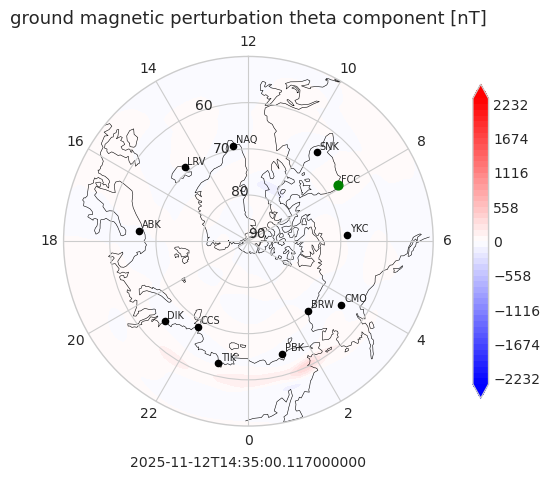

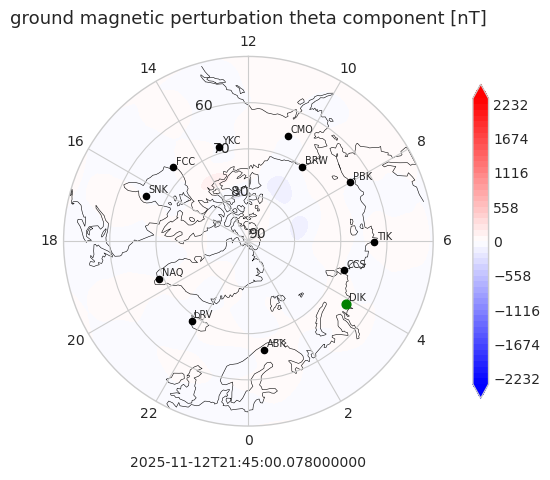

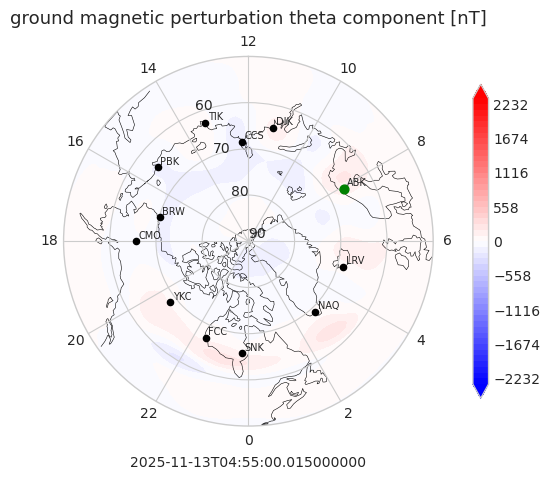

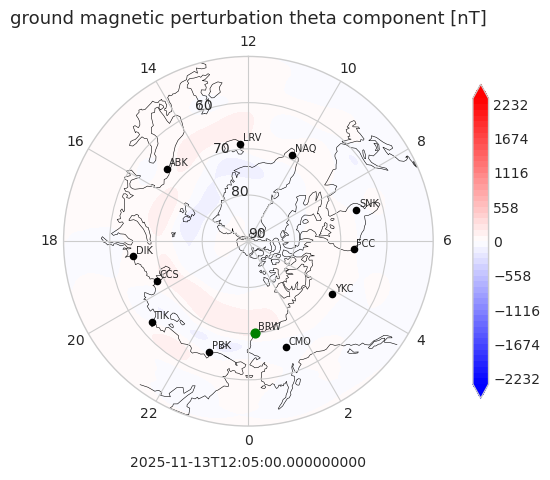

In [35]:
# Ground magnetic perturbation theta component
delbt = iof["delbt"]
delbt *= 1e9

abs_max = abs(delbt).max().values
levels = np.linspace(-abs_max, abs_max, 51)

for i in range(0, time_max, interval):
    current_station = ggcm_al["ggcm.al_station"].isel(time=i).item()
    delbt.isel(time=i).ggcm.plot(
        coastlines=True,
        stations=True,
        highlight_station=current_station,
        levels=levels,
        timestamp=True,
    )

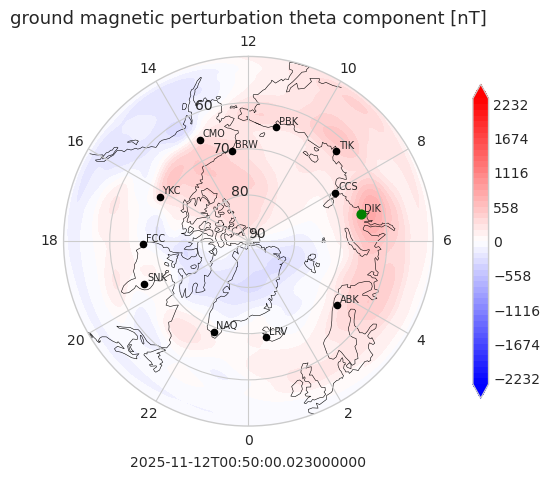

In [36]:
# Ground magnetic perturbation theta component where the station max occurred
current_station = (
    ggcm_al["ggcm.al_station"]
    .sel(time=ggcm_al["ggcm.al"].idxmin().values)
    .item()
)
delbt.sel(time=ggcm_al["ggcm.al"].idxmin().values).ggcm.plot(
    coastlines=True,
    stations=True,
    highlight_station=current_station,
    levels=levels,
    timestamp=True,
)

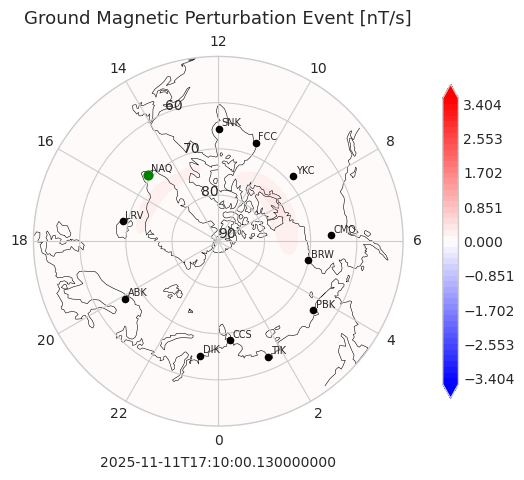

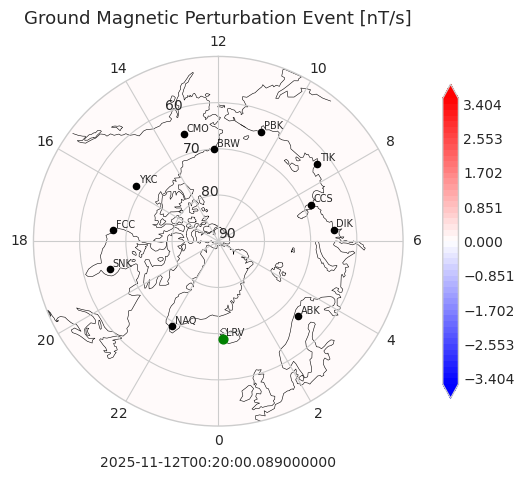

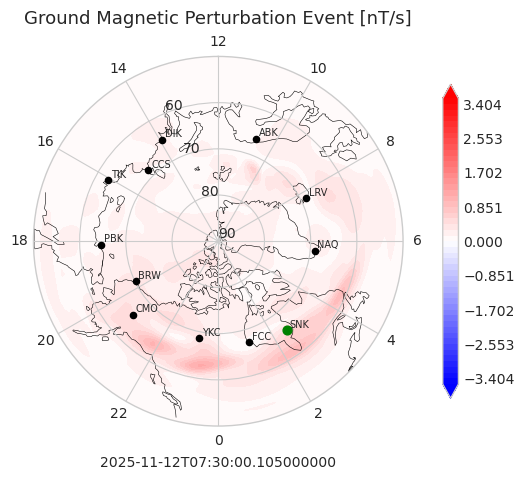

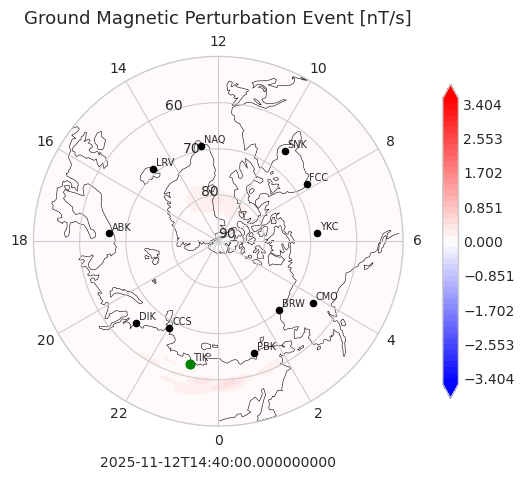

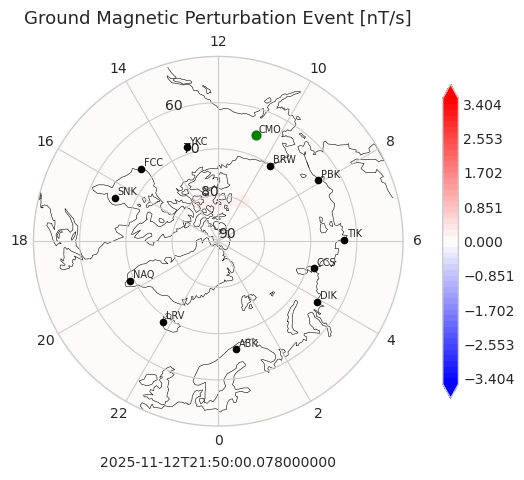

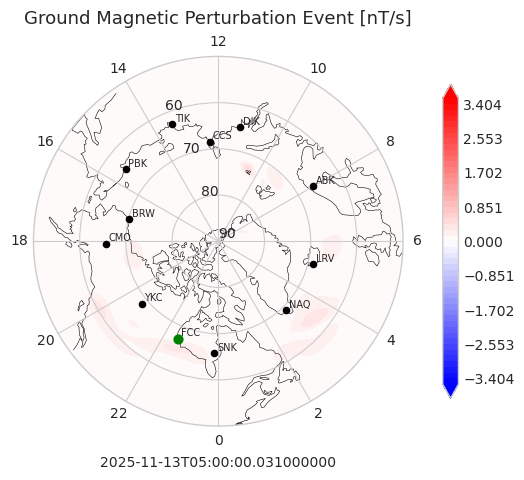

In [37]:
# Ground magnetic perturbation event
# abs_max = abs(delbh_t_sim).max().values
abs_max = abs(delbh_t_sim_station).max().values
levels = np.linspace(-abs_max, abs_max, 51)

for i in range(1, time_max, interval):
    station_max_sim_name_current = (
        delbh_t_sim_station.isel(time=i).idxmax(dim="station").item()
    )
    current_station = station_max_sim_name_current
    delbh_t_sim.isel(time=i).ggcm.plot(
        coastlines=True,
        stations=True,
        highlight_station=current_station,
        levels=levels,
        timestamp=True,
    )

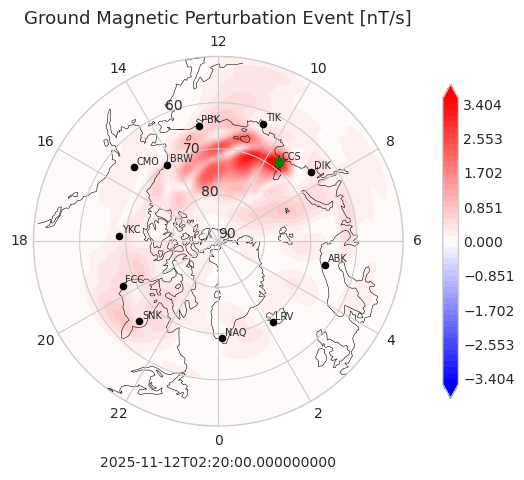

In [38]:
# Ground magnetic perturbation event where the station max occurred
current_station = station_max_sim_name
delbh_t_sim.sel(time=station_max_sim_time).ggcm.plot(
    coastlines=True,
    stations=True,
    highlight_station=current_station,
    levels=levels,
    timestamp=True,
)

In [39]:
# %%capture
output_dir = "figs"
os.makedirs(output_dir, exist_ok=True)

abs_max = abs(delbh_t_sim_station).max().values
levels = np.linspace(-abs_max, abs_max, 51)

for i in range(1, time_max):
    station_max_sim_name_current = (
        delbh_t_sim_station.isel(time=i).idxmax(dim="station").item()
    )
    current_station = station_max_sim_name_current
    delbh_t_sim.isel(time=i).squeeze().ggcm.plot(
        coastlines=True,
        stations=True,
        highlight_station=current_station,
        levels=levels,
        timestamp=True,
    )

    timestamp = delbh_t_sim.time.values[i]
    time_str = np.datetime_as_string(timestamp, unit="s").replace(":", "")

    filename = f"dBdt_frame_{time_str}.png"
    filepath = os.path.join(output_dir, filename)

    plt.savefig(filepath, dpi=300)
    plt.close("all")